## makemore: becoming a backprop ninja

In [ ]:
# there no change change in the first several cells from last lecture

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# ok biolerplate done, now we get to the action:

In [5]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [6]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [7]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [8]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3516, grad_fn=<NegBackward0>)

In [9]:
# Logprobs scratchpad
logprobs.shape
"""
loss = -(a1+a2+...+a32)/32
in other words, we sum all participating components multiplied by the same constant factor of -1/n
and so the partial derivative of the loss w.r.t. any component is simply -1/n
and the partial derivative of the loss w.r.t. any non-participating component is intuitively 0
dloss/da1 = -1/32
"""

'\nloss = -(a1+a2+...+a32)/32\nin other words, we sum all participating components multiplied by the same constant factor of -1/n\nand so the partial derivative of the loss w.r.t. any component is simply -1/n\nand the partial derivative of the loss w.r.t. any non-participating component is intuitively 0\ndloss/da1 = -1/32\n'

In [11]:
# probs scratchpad
probs.shape

# probs is identically shaped as logprobs, and the only operation done is taking the log (natural log?)
# so the same operation is performed on each element to go from probs to logprobs, and we know the derivative
# of ln(x) = 1/x, and all we need now is to take the chain rule so multiply by dlogprobs


torch.Size([32, 27])

In [12]:
# counts, counts_sum, counts_sum_inv scratchpad
counts_sum_inv.shape
counts.shape
counts_sum.shape

# probs = counts * counts_sum_inv elementwise multiplication takes exponentiated logits and divides by sum which normalizes into probabilities
# counts is (32, 27) while counts_sum_inv is (32,1)
# so the derivatives are just each other (since they are each other's coefficients in the partial derivatives)
# but WAIT! I mixed up counts and counts_sum, so the dimensions are different and pytorch will broadcast counts_sum_inv across counts
# so the operation to calculate probs also includes broadcasting (how do I backprop through that?? apparently we sum across dimension 1 and dont forget to keepdim)
# summing across dim 1 is equivalent to summing the contributions of each individual counts_sum_inv across the 27 dimensions; recall when one value contributes to multiple gradients we sum the gradients
# same logic for dcounts, except we also need to consider how tensor dimensions affect backprop
# so we do dcounts_sum first, which means differentiating counts_sum**-1 = -counts_sum**-2
# now for counts: we have gradients flowing from counts_sum = counts.sum(1, keepdims=True) and probs = counts * counts_sum_inv so we calculate those independently then add
# Differentiating addition is simply 1 (for partial diff, everything else becomes a constant and coefficient of variable is 1)
# And we also have probs = counts * counts_sum_inv, so by chain rule this section is equal to counts_sum_inv * dprobs


torch.Size([32, 1])

In [15]:
# logits scratchpad
norm_logits.shape
dcounts.shape
logit_maxes.shape

# counts = norm_logits.exp() is a very simple element-wise exponentiation function and derivative of e^x is e^x with chain rule
# norm_logits = logits - logit_maxes is also a simple addition so factor of logit_maxes which is -1 multiplied by gradient summed between dim 1 tells us how much each max contributes
# logit_maxes = logits.max(1, keepdim=True).values and norm_logits = logits - logit_maxes give 2 components contributing gradients to 'logits'; for the first we simply want to
# pass through the gradients from dlogit_maxes for all logit_maxes and the second simply passthrough dnorm_logits (diff of addition is 1) and sum both


torch.Size([32, 1])

In [16]:
# output layer scratchpad
h.shape, W2.shape, b2.shape, dlogits.shape

# how do we differentiate matmul?? Andrej says it's not as hard as you'd expect and it's derivable from first principles using a small example and pen & paper
# i will be back!
# maybe create another matrix with the same dimensions, then each column-wise element in the other factor becomes the derivative of the row-wise element of the original
# i.e: given a MxN matrix and a NxK matrix, differentiating the matmul for the MxN produces the MxN matrix whereby each Nth element in the NxK column is the derivative along the Nth row in the MxN
# and then chain rule? I'm not sure how the broadcasting of dimensions works here but it's worth a shot
# writing everything out this becomes the matrix of gradients multiplied by the transpose of the other factor


(torch.Size([32, 64]),
 torch.Size([64, 27]),
 torch.Size([27]),
 torch.Size([32, 27]))

In [19]:
# hidden layer & batchnorm scratchpad
dh.shape, hpreact.shape
bngain.shape, bnraw.shape, bnbias.shape, dhpreact.shape
bnvar_inv.shape, bndiff.shape, dbnraw.shape
bndiff2.shape, dbnvar.shape
dbndiff2.shape, bndiff.shape
bnmeani.shape, dbndiff.shape, hprebn.shape

# so their (hpreact and dh) dimensions are the same which makes me think the backward pass here is simply whatever the derivative of tanh is applied element-wise across the tensor
# hpreact = bngain * bnraw + bnbias is once again products and sums which we've differentiated a million times already
# bnraw = bnvar_inv * bndiff is once again a product
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) bndiff2 is summed across dim 0 so maybe we just broadcast across bndiff2's 32 dims? also don't forget the 1/(n-1) up front
# and now we have the other component for bndiff: bndiff2 = bndiff**2
# bndiff = hprebn - bnmeani is another simple sum (with -1 factor for the subtracted tensor) and we need to sum over dim 0 for bnmeani
# but hprebn has another component: bnmeani = 1/n*hprebn.sum(0, keepdim=True)


(torch.Size([1, 64]), torch.Size([32, 64]), torch.Size([32, 64]))

In [37]:
# linear layer 1 & embeddings scratchpad
dhprebn.shape, embcat.shape, W1.shape, b1.shape
dembcat.shape, emb.shape, C.shape, Xb.shape

# Onto the final portion, we have the following ops:
# emb = C[Xb] # embed the characters into vectors
# embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# For embcat, it looks like matmul between dhprebn and W1.transpose, and it is!
# For W1, it looks like embcat.transpose matmul dhprebn, this is matmul pt2 electric boogaloo
# embcat is just a view change of emb so we just view change back (no numerical changes done, so all the gradients are the same)
# Finally, emb = C[Xb], we need to route the gradients through to C by finding the 'active characters'


(torch.Size([32, 30]),
 torch.Size([32, 3, 10]),
 torch.Size([27, 10]),
 torch.Size([32, 3]))

In [9]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

# -----------------
# YOUR CODE HERE :)

# -----------------
dlogprobs = torch.zeros((batch_size, vocab_size))         # alternatively Karpathy uses torch.zeros_like(logprobs) which generates a zero tensor in the shape of logprobs
dlogprobs[range(n), Yb] = -1.0/batch_size                 # and then we index the participating components identically
# -----------------
dprobs = 1.0/probs * dlogprobs                            # The local derivative of ln(x) = 1/x, and then take chain rule which is multiply by previous partial derivative dlogprobs
# -----------------
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)  # Differentiating multiplication is simply the coefficient * partial gradient; then sum the 27 gradients that counts_sum_inv contributes to
# -----------------
dcounts_sum = -counts_sum**-2 * dcounts_sum_inv           # Power rule + chain rule
# -----------------
dcounts = counts_sum_inv * dprobs + dcounts_sum           # counts_sum_inv * dprobs + 1 * dcounts_sum because multiplication component differentiates to the other factor and sum component becomes 1, then chain rule
# -----------------
dnorm_logits = norm_logits.exp() * dcounts                # diff of e^x is e^x; also chain rule
# -----------------
dlogit_maxes = (dnorm_logits * -1.0).sum(1, keepdim=True) # diff of addition is 1 (subtraction is -1) and sum again to combine gradients for same value
# -----------------
# dlogits = dnorm_logits + logit_maxes * dlogit_maxes       # diff of addition is 1 and sum with other component which is dlogit_maxes only for the logit_maxes
dlogits = dnorm_logits + F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes   # version above is slightly off, because the local derivative of max() is 1 for selected values, not the values themselves
# -----------------
dh = dlogits @ W2.transpose(0, 1)                         # differentiating matmul becomes gradient @ transpose of other matrix
# -----------------
dW2 = h.transpose(0, 1) @ dlogits                         # same principle here, in actuality the only way to matmul that works out dimensionality-wise gives the correct result (Andrej-approved method)
# -----------------
db2 = dlogits.sum(0, keepdim=True)                        # the dimensionality of the tensors hint at what db2 should be (especially when differentiating sums is just 1)
# -----------------
dhpreact = (torch.ones_like(dh) - torch.tanh(hpreact)**2) * dh # derivative of tanh is apparently 1-tanh()^2
# -----------------
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)         # like I said, products and sums
# -----------------
dbnbias = dhpreact.sum(0, keepdim=True)                   # Products and sums....
# -----------------
dbnraw = (bngain * dhpreact)                              # PRODUCTS AND SUMS!!!
# -----------------
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)       # another product...
# -----------------
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv         # power rule but don't forget the small epsilon inside!
# -----------------
dbndiff2 = 1/(n-1) * torch.ones_like(bndiff2) * dbnvar    # differentiating a squashing sum is a broadcasting passthrough
# -----------------
dbndiff = (dbnraw * bnvar_inv) + (2 * bndiff * dbndiff2)  # 2 components: 1 product and 1 power
# -----------------
dbnmeani = (-1.0 * dbndiff).sum(0, keepdim=True)          # This one and the next form a sum again
# -----------------
dhprebn = (dbndiff) + (1/n * torch.ones_like(hprebn) * dbnmeani) # We got the sum component up front and the dbnmeani component next, which is once again a sum with a constant factor 1/n
# -----------------
dembcat = dhprebn @ W1.transpose(0, 1)                    # For this and the next two, we matmul/sum by scrutinizing tensor dims (goated strat)
# -----------------
dW1 = embcat.transpose(0, 1) @ dhprebn                    # May have seen that it's the same as the batchnorm
# -----------------
db1 = dhprebn.sum(0, keepdim=True)                        # Same here
# -----------------
demb = dembcat.view(emb.shape)                            # embcat is just emb concatenated (no change to any numerical values) so we just need to change the tensor to the right shape (to prevent hardcoding use emb.shape)
# -----------------
dC = torch.zeros_like(C)                                  # Init dC as a zero tensor with same shape as C
for k in range(Xb.shape[0]):                              # For each character present in Xb
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]                                      # Find its index
        dC[ix] += demb[k,j]                               # and add to dC (at its index) its corresponding value from the previous gradient
# -----------------

# END
# -----------------

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnbias          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnraw   

In [10]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3516149520874023 diff: 0.0


In [11]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = F.softmax(logits, 1)             # TODO. my solution is 3 lines
dlogits[range(n), Yb] -= 1
dlogits /= n
# -----------------

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 5.005858838558197e-09


In [12]:
F.softmax(logits, 1)[0]

tensor([0.0585, 0.0900, 0.0183, 0.0496, 0.0189, 0.0802, 0.0268, 0.0355, 0.0195,
        0.0306, 0.0401, 0.0367, 0.0395, 0.0294, 0.0345, 0.0138, 0.0087, 0.0196,
        0.0175, 0.0611, 0.0486, 0.0204, 0.0256, 0.0719, 0.0580, 0.0257, 0.0209],
       grad_fn=<SelectBackward0>)

In [13]:
dlogits[0] * n
# notice that this is identical to the above EXCEPT for the correct label which is now a massive -0.9810 (the black square in the figure below)

tensor([ 0.0585,  0.0900,  0.0183,  0.0496,  0.0189,  0.0802,  0.0268,  0.0355,
        -0.9805,  0.0306,  0.0401,  0.0367,  0.0395,  0.0294,  0.0345,  0.0138,
         0.0087,  0.0196,  0.0175,  0.0611,  0.0486,  0.0204,  0.0256,  0.0719,
         0.0580,  0.0257,  0.0209], grad_fn=<MulBackward0>)

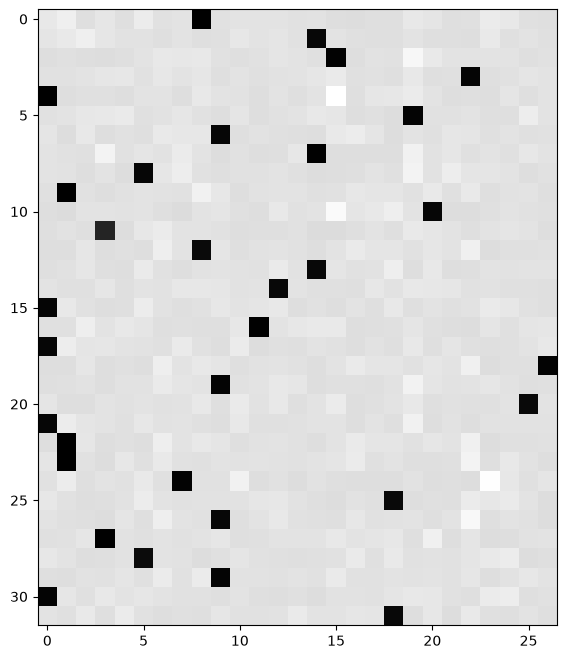

In [14]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray')

In [18]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [20]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
dhprebn = bngain * bnvar_inv/n * (n * dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0)) # TODO. my solution is 1 (long) line
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [43]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

    # kick off optimization
    for i in range(max_steps):
    
      # minibatch construct
      ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
      Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
      # forward pass
      emb = C[Xb] # embed the characters into vectors
      embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
      # Linear layer
      hprebn = embcat @ W1 + b1 # hidden layer pre-activation
      # BatchNorm layer
      # -------------------------------------------------------------
      bnmean = hprebn.mean(0, keepdim=True)
      bnvar = hprebn.var(0, keepdim=True, unbiased=True)
      bnvar_inv = (bnvar + 1e-5)**-0.5
      bnraw = (hprebn - bnmean) * bnvar_inv
      hpreact = bngain * bnraw + bnbias
      # -------------------------------------------------------------
      # Non-linearity
      h = torch.tanh(hpreact) # hidden layer
      logits = h @ W2 + b2 # output layer
      loss = F.cross_entropy(logits, Yb) # loss function
    
      # backward pass
      for p in parameters:
        p.grad = None
      # loss.backward() # use this for correctness comparisons, delete it later!
    
      # manual backprop! #swole_doge_meme
      # -----------------
      # YOUR CODE HERE :)
      dlogits = F.softmax(logits, 1)
      dlogits[range(n), Yb] -= 1
      dlogits /= n
      dh = dlogits @ W2.transpose(0, 1)
      dW2 = h.transpose(0, 1) @ dlogits
      db2 = dlogits.sum(0, keepdim=False)
      dhpreact = (torch.ones_like(dh) - torch.tanh(hpreact)**2) * dh
      dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
      dbnbias = dhpreact.sum(0, keepdim=True)
      dhprebn = bngain * bnvar_inv/n * (n * dhpreact - dhpreact.sum(0) - n/(n-1) * bnraw * (dhpreact * bnraw).sum(0))
      dembcat = dhprebn @ W1.transpose(0, 1)
      dW1 = embcat.transpose(0, 1) @ dhprebn
      db1 = dhprebn.sum(0, keepdim=False)
      demb = dembcat.view(emb.shape)
      dC = torch.zeros_like(C)
      for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
          ix = Xb[k,j]
          dC[ix] += demb[k,j]
      grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
      # -----------------
    
      # update
      lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
      for p, grad in zip(parameters, grads):
        # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
        p.data += -lr * grad # new way of swole doge TODO: enable
    
      # track stats
      if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      lossi.append(loss.log10().item())
    
      # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
      #   break

12297
      0/ 200000: 3.7584
  10000/ 200000: 2.1652
  20000/ 200000: 2.3814
  30000/ 200000: 2.5324
  40000/ 200000: 1.9502
  50000/ 200000: 2.3609
  60000/ 200000: 2.4279
  70000/ 200000: 2.0755
  80000/ 200000: 2.2943
  90000/ 200000: 2.1299
 100000/ 200000: 1.9767
 110000/ 200000: 2.2902
 120000/ 200000: 2.0668
 130000/ 200000: 2.4468
 140000/ 200000: 2.3280
 150000/ 200000: 2.2141
 160000/ 200000: 1.9803
 170000/ 200000: 1.8076
 180000/ 200000: 2.0728
 190000/ 200000: 1.9139


In [40]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(200,)          | exact: False | approximate: True  | maxdiff: 4.6566128730773926e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
(27,)           | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 2.3283064365386963e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09


In [44]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [45]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0703394412994385
val 2.107590913772583


In [ ]:
# Andrej achieved:
# train 2.0718822479248047
# val 2.1162495613098145
# I had:
# train 2.0703394412994385
# val 2.107590913772583
# Very similar results across the board

In [46]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzamille.
khi.
mri.
reet.
khalaysie.
rahnen.
delynn.
jareei.
nellara.
chaiivon.
leigh.
ham.
joca.
quinn.
salin.
alianni.
wavero.
dearyxia.
kaellinsley.
daedo.


In [ ]:
# There it is! We're done!